# Lever 1 -- Instrument choice: TSLA call vs. TSLL call

Self-contained (own data load, own formulas, nothing imported from `deprecated/` or any
other notebook).

**Question**: when it's time to buy protection, do we buy a call on TSLA (the stock) or
TSLL (the ETF itself)? Three arms, compared on the train window only:

- `cost_benefit`: at every roll, price both, buy whichever is cheaper for equal target
  dollar-delta coverage, with real trading volume required; fall back to the other if
  one's unavailable that day.
- `tsla_only`: always TSLA calls.
- `tsll_only`: always TSLL calls.

Held fixed for this test (not yet determined by Lever 2 -- simple, round, provisional
choices, re-checked once Lever 2 locks in real values): moneyness = ATM, target DTE = 90,
roll trigger DTE = 14. `ESTIMATION_WINDOW = 21` (stated convention, not tested -- see the
project README).

Train window starts 2022-09-09, not 2022-08-12 -- TSLL's price history only begins
2022-08-09, so the first ~19 trading days have no genuine 21-day trailing window to
estimate sigma/beta from. Starting the window here means every day used has a real
trailing estimate, not a backfilled one.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, risk metrics

In [3]:
R_RF = 0.05             # stated assumption, not estimated (per project scope)
ESTIMATION_WINDOW = 21   # stated convention (~1 trading month), not tested/optimized

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    """Black-Scholes European call delta = N(d1). Clipped to [0.01, 1.0] to keep
    downstream sizing finite."""
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_df, spot_series, date, moneyness_bucket, target_dte, max_dte):
    """Filter to the moneyness bucket, require a real fill (px_last>0, px_volume>0),
    require positive DTE within max_dte, pick the contract closest to target_dte.
    Moneyness is ALWAYS bounded to the queried bucket -- never an unbounded strike search
    (that bug already blew up a position 22x earlier this project)."""
    day = calls_df[calls_df["date"] == date]
    if day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    """Delta-neutral contract count for a given target dollar-delta. Returns
    (n_contracts, cost_dollars, entry_price). CONTRACTS, not shares -- each contract
    covers 100 shares, so cost = n_contracts * 100 * entry_price, always. That /100 unit
    conversion caused a 100x position-sizing bug earlier this project; it's isolated in
    exactly one place (this function) on purpose."""
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 else end ** (1 / n_years) - 1


def ann_vol(returns):
    return returns.std() * np.sqrt(252)


def sharpe(returns, rf=0.0):
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()


def summarize(equity, returns, name):
    return {"Strategy": name, "CAGR": cagr(equity), "Ann. Vol": ann_vol(returns),
            "Sharpe": sharpe(returns), "Max DD": max_drawdown(equity)}

## Train window (same split used throughout this rebuild)

In [4]:
TRAIN_START = pd.Timestamp("2022-09-09")  # first date with a genuine (non-bfilled) 21-day window
TRAIN_END = pd.Timestamp("2023-01-03")
train_dates = dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)]
print(f"Train window: {len(train_dates)} days, {train_dates.min().date()} -> {train_dates.max().date()}")

# provisional, fixed-for-this-test dimensions -- Lever 2 determines the real ones
MONEYNESS_BUCKET = "ATM"
TARGET_DTE = 90
ROLL_DTE = 14
MAX_DTE = 110

Train window: 80 days, 2022-09-09 -> 2023-01-03


## Simulation -- short TSLL (buy & hold) + rolling call, instrument chosen per `selection_rule`

In [5]:
def simulate_instrument_choice(sim_dates, selection_rule, notional=1.0):
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None  # dict: underlying, raw_id, strike, expiry, n, price
    S_prev = S_incep
    stats = {"rolls": 0, "fills_tsla": 0, "fills_tsll": 0, "misses": 0}

    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        calls_df = tsla_calls if pos["underlying"] == "tsla" else tsll_calls
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        row = calls_df[(calls_df["raw_id"] == pos["raw_id"]) & (calls_df["date"] == date)]
        if row.empty or pd.isna(row["px_last"].iloc[0]):
            return pos["price"]
        return float(row["px_last"].iloc[0])

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        held_dte = (position["expiry"] - d).days if position is not None else -1
        need_roll = position is None or held_dte < ROLL_DTE

        if need_roll:
            if position is not None:
                stats["rolls"] += 1
            # short leg is a $1-for-$1 TSLL exposure, so a TSLL call needs target dollar
            # delta = notional directly. A TSLA call's delta lives in TSLA-price terms, so
            # it needs to be scaled by beta to translate into TSLL-equivalent coverage --
            # using the SAME (beta-scaled) target for both legs was the bug that made
            # tsll_only buy ~beta-times too much option (beta ~= 1.5-2x here), which is
            # what actually caused its collapse, not TSLL being a bad hedge instrument.
            beta_t = float(beta_tsll_vs_tsla.loc[d])
            target_dollar_delta_tsla = beta_t * notional
            target_dollar_delta_tsll = notional
            sig_tsla = float(tsla_sigma.loc[d])
            sig_tsll = float(tsll_sigma.loc[d])

            row_tsla = select_contract(tsla_calls, tsla_spot, d, MONEYNESS_BUCKET, TARGET_DTE, MAX_DTE)
            row_tsll = select_contract(tsll_calls, tsll_spot, d, MONEYNESS_BUCKET, TARGET_DTE, MAX_DTE)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), sig_tsla, target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), sig_tsll, target_dollar_delta_tsll, d)

            chosen = None
            if selection_rule == "tsla_only" and row_tsla is not None:
                chosen = "tsla"
            elif selection_rule == "tsll_only" and row_tsll is not None:
                chosen = "tsll"
            elif selection_rule == "cost_benefit":
                if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                    chosen = "tsla"
                elif row_tsll is not None:
                    chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
                stats["fills_tsla"] += 1
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
                stats["fills_tsll"] += 1
            else:
                position = None
                stats["misses"] += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, stats

## Run all three arms on the train window

In [6]:
results = {}
for rule in ["cost_benefit", "tsla_only", "tsll_only"]:
    eq, stats = simulate_instrument_choice(train_dates, rule)
    results[rule] = (eq, stats)
    print(f"{rule}: rolls={stats['rolls']} fills_tsla={stats['fills_tsla']} "
          f"fills_tsll={stats['fills_tsll']} misses={stats['misses']}")

cost_benefit: rolls=4 fills_tsla=4 fills_tsll=1 misses=2


tsla_only: rolls=4 fills_tsla=5 fills_tsll=0 misses=2
tsll_only: rolls=1 fills_tsla=0 fills_tsll=2 misses=14


In [7]:
rows = [summarize(eq, eq.pct_change().dropna(), rule) for rule, (eq, _) in results.items()]
metrics_df = pd.DataFrame(rows)
metrics_df

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD
0,cost_benefit,0.501916,0.548713,1.024695,-0.193615
1,tsla_only,0.051065,0.344785,0.316106,-0.212203
2,tsll_only,1.873257,0.584874,2.125132,-0.168101


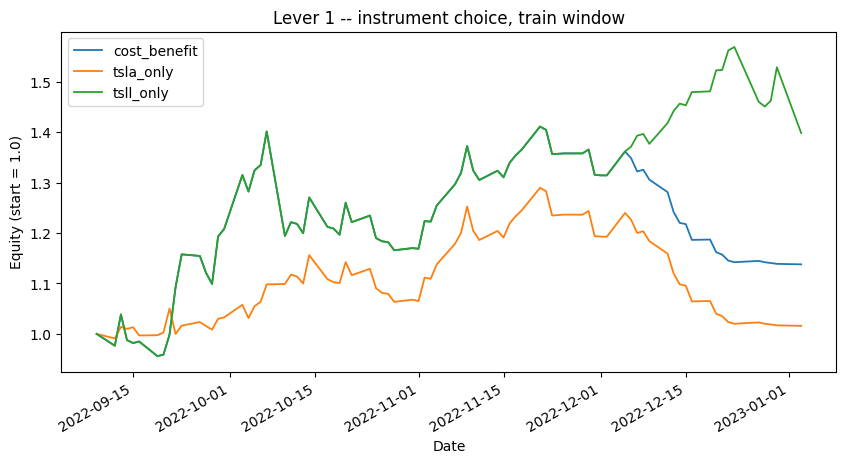

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for rule, (eq, _) in results.items():
    eq.plot(ax=ax, label=rule, linewidth=1.3)
ax.set_title("Lever 1 -- instrument choice, train window")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend()
plt.show()

## Sanity checks

In [9]:
for rule, (eq, stats) in results.items():
    assert eq.isna().sum() == 0, f"{rule}: equity has NaNs"
print("Lever 1 sanity checks passed -- no NaNs in any arm's equity curve.")
print(f"\nWinner on train Sharpe: {metrics_df.loc[metrics_df['Sharpe'].idxmax(), 'Strategy']}")

Lever 1 sanity checks passed -- no NaNs in any arm's equity curve.

Winner on train Sharpe: tsll_only
